## Astronomy 3350
### Autumn 2025
#### Lab 8 - October 28 and 30, 2025

### Goals

We will examine a data file containing measurements of relatively
nearby stars in the direction of the IC4665 open cluster.  Distant
stars are excluded in order to keep the file size to a minimum. In
this laboratory, we will do a first pass to identify where IC4665 
is located in proper motion space and in distance in this data file.
We will do much more detailed analysis as part of your next computational
essay.

This lab makes heavy use of material covered in class on October 24
and 27.

### Instructions

Solve each problem in order.  When your notebook is complete, save it, run it in its
entirety, and upload the notebook to Carmen.  If you need more time, you may submit
it before 5:00 p.m. on Friday, October 31.

The problems are below after a few programming items. Please read over the code under
'preliminaries' it will show you a few techniques that are useful in this lab.

This notebook requires a data file, which is available on Carmen.

### Preliminaries

1. Import packages.
2. Read the data file and report its length.
3. Print a table of the definitions of all the series in the data frame.
4. Plot the coordinates of all the stars in the file to illustrate how to access individual series (or columns).


In [1]:
# Get plotting and pandas
import matplotlib.pyplot as plt
import pandas as pd

# Read the file into a dataframe called IC.
infile = 'IC4665_lab.txt'
IC = pd.read_csv(infile)

# Print the length of the file.
print('The data file %s has %d entries' % (infile, len(IC)) )

# Names of the data series (columns).
print(IC.columns)

The data file IC4665_lab.txt has 124829 entries
Index(['Unnamed: 0', 'source_id', 'ra', 'dec', 'parallax', 'pmra', 'pmdec',
       'phot_g_mean_mag', 'phot_bp_mean_mag', 'phot_rp_mean_mag'],
      dtype='object')


__Table of series names and their meaning:__ 

| name | meaning |
| ----- | ----- |
| source_id | unique identifier for each star in Gaia data release 3 |
| ra | right ascension (degree) |
| dec | declination (degree) |
| parallax | observed parallax (milliarcsecond) |
| pmra | proper motion in right ascension (milliarcsecond per year) |
| pmdec | proper motion in declination (milliarcsecond per year) |
| phot_g_mean_mag | G-band magnitude |
| phot_bp_mean_mag | Bp-band magnitude (blue) |
| phot_rp_mean_mag | Rp-band magnitude (red) |


__Plot the coordinates.__ The x-axis is reversed because this produces the same orientation as
on the sky (right asension increases to the east).  Since the data on both axes have the same
units, we set the aspect ratio accordingly.

We want tiny little points since there are so many of them. See [this page on marker styles](https://matplotlib.org/stable/api/markers_api.html) for matplotlib plots.

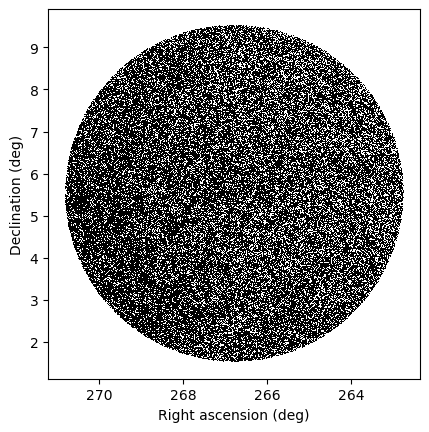

In [2]:
# Scribe the plot
fig, ax = plt.subplots()
ax.plot(IC['ra'], IC['dec'], ',k')
ax.set_xlabel('Right ascension (deg)')
ax.set_ylabel('Declination (deg)')
ax.set_aspect('equal')
ax.invert_xaxis()

----

## Begin problems 

### Problem 0

In the Markdown cell below this one, list all team members with their OSU name.number.

Also include a participation code which I will give you.

- Jungyu Baeck

### Problem 1

Using the template above, plot (x-axis) the proper motion in right
ascension and (y-axis) the proper motion in declination.  Be sure 
to make the axis labels correcly indicate what quantities are being
plotted.

__Discuss:__ Do you see any clustering in proper motion which would
indicate the average motion of the IC 4665 cluster?  Is this plot even
helpful?  What would you need to do to improve it?

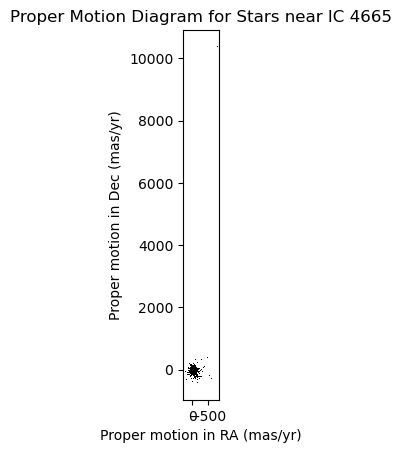

In [3]:
# Your code here.
fig, ax = plt.subplots()
ax.plot(IC['pmra'], IC['pmdec'], ',k')   
ax.set_xlabel('Proper motion in RA (mas/yr)')
ax.set_ylabel('Proper motion in Dec (mas/yr)')
ax.set_title('Proper Motion Diagram for Stars near IC 4665')
ax.set_aspect('equal')
ax.invert_xaxis()

I can see a dense concentration of points in proper motion which would indicate the average motion of the IC 4665 cluster.
This plot provides a first look at the cluster’s mean motion. However, because there are mant points, the plot can appear very crowded.

I can limit the axis to improve this:

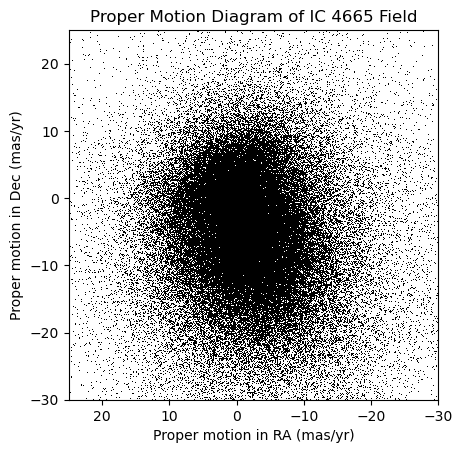

In [4]:
fig, ax = plt.subplots()
ax.plot(IC['pmra'], IC['pmdec'], ',k')

ax.set_xlim(-30, 25)
ax.set_ylim(-30, 25)
ax.set_xlabel('Proper motion in RA (mas/yr)')
ax.set_ylabel('Proper motion in Dec (mas/yr)')
ax.set_title('Proper Motion Diagram of IC 4665 Field')
ax.set_aspect('equal')
ax.invert_xaxis()


### Problem 2

Copy the code above, but add x-axis and y-axis limits with `ax.set_xlim(low, high)`
to isolate a region on the plot.

Look up the cluster proper motion at
[Simbad](https://simbad.u-strasbg.fr/simbad/sim-basic?Ident=IC4665&submit=SIMBAD+search) to identify where the cluster is
supposed to be.

__Discuss:__ is there a clumping of points near the expected proper motion when
we use all the stars in the data file?

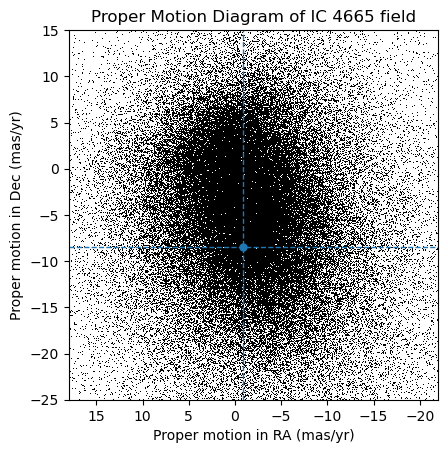

In [5]:
fig, ax = plt.subplots()
ax.plot(IC['pmra'], IC['pmdec'], ',k')

mu_alpha = -0.90   # mas/yr  
mu_delta = -8.51   # mas/yr

ax.set_xlim(-22, 18)
ax.set_ylim(-25, 15)
ax.axvline(mu_alpha, ls='--', lw=1)
ax.axhline(mu_delta, ls='--', lw=1)
ax.plot(mu_alpha, mu_delta, 'o', ms=5)
ax.set_xlabel('Proper motion in RA (mas/yr)')
ax.set_ylabel('Proper motion in Dec (mas/yr)')
ax.set_title('Proper Motion Diagram of IC 4665 field')
ax.set_aspect('equal')
ax.invert_xaxis()

Yes, the proper motion plot shows a very slight clumping near proper point

### Problem 3

Let's try selecting stars with a narrower range of parallax, to isolate
stars that are around where the cluster is supposed to be.

First, use the .max() and .min() methods to report the largest
and smallest parallax in the sample.  Compare that to the average
parallax for the cluster reported in Simbad.  In your discussion, 
please propose a range of parallaxes you want to select to look for
the cluster in parameter space. Do this with (for example)

`value = frame['series'].max()`

like this:

`ra_max = IC['ra'].max()`

Also report the average distance to the cluster from Simbad, in
units of parsec.  If $p$ is the parallax in millarcsec, the distance
$d$ in parsec is given by $d = 1000 / p$.

We will select stars over a range in parallax in a subsequent problem.

In [6]:
parallax_min = IC['parallax'].min()
parallax_max = IC['parallax'].max()
print("Minimum parallax in sample: %.3f mas" % parallax_min)
print("Maximum parallax in sample: %.3f mas" % parallax_max)

p_cluster = 2.9  # mas
d_cluster = 1000 / p_cluster  # pc
print("Cluster average parallax: %.2f mas" % p_cluster)
print("Cluster average distance: %.1f pc" % d_cluster)

Minimum parallax in sample: 1.000 mas
Maximum parallax in sample: 546.976 mas
Cluster average parallax: 2.90 mas
Cluster average distance: 344.8 pc


In simbad, Parallax: 2.8918 ± 0.0034 mas, d = 346 pc
I have     Parallax: 2.90 mas,            d = 344.8 pc

quite close results to those in simbad

### Problem 4

You can define a restricted _data view_ of a pandas frame with the following
syntax.  For example, to pick values below some value, use:

`view = frame[frame['series'] < value]`

If you want to pick an upper and lower bound, the syntax is a little more
complex:

`view = frame[ (frame['series'] >= lower_bound) & (frame['series'] <= upper_bound) ]`

Use this construction to pick out only those stars within a selected
range of parallax.  Report the number of stars that met your criterion.

This is called a _data view_ because it is not a copy of those data which
meet your criterion.  You are defining a restricted view of only those points
in the original frame that pass whatever test you give.

__Important:__ The name of the data view must not be the same as the original 
frame.

In [7]:
## select stars with parallaxes close to 2.9 mas
lower_bound = 2.4
upper_bound = 3.4

IC_parallax_view = IC[(IC['parallax'] >= lower_bound) & (IC['parallax'] <= upper_bound)]

n_selected = len(IC_parallax_view)
print("Number of stars in parallax range %.2f–%.2f mas: %d" % (lower_bound, upper_bound, n_selected))

IC_parallax_view.head()

Number of stars in parallax range 2.40–3.40 mas: 11643


,Unnamed: 0,source_id,ra,dec,parallax,pmra,pmdec,phot_g_mean_mag,phot_bp_mean_mag,phot_rp_mean_mag
6,124,4471464342767668736,270.765420,5.369416,2.550814,-6.538706,-8.936367,15.445642,16.270212,14.555694
27,630,4471288627064225920,270.706438,4.778953,3.170320,1.614846,-4.847391,13.927896,14.519058,13.189678
28,663,4471288760203885696,270.731121,4.794152,2.740765,13.544033,-2.701332,18.439825,20.150057,17.206053
33,739,4471300476873084160,270.355926,4.509215,2.789248,-26.985779,-7.821642,14.318089,14.893456,13.582748
44,1066,4471301060988829824,270.421660,4.544071,2.433734,23.077429,23.599761,19.223623,21.040997,18.073496


Number of stars in parallax range 2.20–3.60 mas: 17189
Number of stars in parallax range 2.30–3.50 mas: 14277
Number of stars in parallax range 2.40–3.40 mas: 11643
Number of stars in parallax range 2.50–3.30 mas: 9188

Out of the original 124,829 stars, only about 1 – 2 % fall within this narrow parallax range. 
These are likely to include genuine IC 4665 members.

### Problem 5

Start with the data view you created above and apply a further selection
to that view to isolate only stars with proper motion values that 
meet some criterion.  Make a plot of the proper motions in the
selection from Problem 5, and show your selection of stars near the cluster
using larger or different colored points.

Report how many stars meet your selection as the most likely members.
What percentage is this of the original sample?

Number of likely members: 665
Fraction of parallax-filtered stars: 5.71%
Fraction of total stars: 0.533%


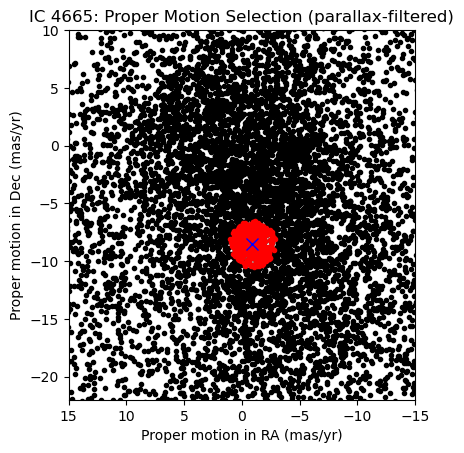

In [8]:

mu_ra_c  = -0.90   # mas/yr
mu_dec_c = -8.51   # mas/yr

## Proper-motion tolerance
radius = 2.0

# Compute distance in proper motion space from cluster mean
dpm = ((IC_parallax_view['pmra'] - mu_ra_c)**2 + 
       (IC_parallax_view['pmdec'] - mu_dec_c)**2)**0.5

IC_members = IC_parallax_view[dpm <= radius]

fig, ax = plt.subplots()
ax.plot(IC_parallax_view['pmra'], IC_parallax_view['pmdec'], '.k', label='Parallax-selected')
ax.plot(IC_members['pmra'], IC_members['pmdec'], 'o', ms=3, color='red', label='Likely members')
ax.plot(mu_ra_c, mu_dec_c, 'x', color='blue', ms=8, label='Cluster centroid')
ax.set_xlabel('Proper motion in RA (mas/yr)')
ax.set_ylabel('Proper motion in Dec (mas/yr)')
ax.set_title('IC 4665: Proper Motion Selection (parallax-filtered)')
ax.set_xlim(-15, 15)
ax.set_ylim(-22, 10)
ax.set_aspect('equal')
ax.invert_xaxis()

# Report counts
n_total = len(IC)
n_parallax = len(IC_parallax_view)
n_members = len(IC_members)
print(f"Number of likely members: {n_members}")
print(f"Fraction of parallax-filtered stars: {100*n_members/n_parallax:.2f}%")
print(f"Fraction of total stars: {100*n_members/n_total:.3f}%")

After applying both the parallax cut (2.2–3.6 mas) and a proper-motion cut centered at (−0.9, −8.5) mas/yr with radius 2.0 mas/yr, about 665 stars appears clearly in the proper-motion plot. They are the most likely members of IC 4665.

Small fraction of 0.533% of all stars are in range.